In [1]:
%run ../src/drug_reaction_analysis.py

Finding reports for DUPIXENT...


FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/drug_data.csv'

In [2]:
import os
os.chdir("..")


In [3]:
%run ../src/drug_reaction_analysis.py

Exception: File `'../src/drug_reaction_analysis.py'` not found.

In [4]:
import os
os.chdir(r"C:\MCA_Projects\SafetySignal-X")
print(os.getcwd())


C:\MCA_Projects\SafetySignal-X


In [5]:
%run src/drug_reaction_analysis.py

Finding reports for DUPIXENT...
DUPIXENT reports found: 34284
Finding adverse reactions...

Top 20 reactions reported with DUPIXENT:
                                    Adverse Reaction  Frequency
0                                           Pruritus       4852
1                                  Dermatitis atopic       4787
2                                Injection site pain       3048
3                                               Rash       2916
4               Product use in unapproved indication       2862
5                                             Eczema       2611
6                                           Dry skin       2194
7                               Condition aggravated       2054
8                                   Drug ineffective       1943
9   Inappropriate schedule of product administration       1893
10                                            Asthma       1752
11                    Accidental exposure to product       1544
12                         Exposure

In [1]:
import os

base_path = r"C:\MCA_Projects\SafetySignal-X\data\raw\faers_ascii_2025q1\ASCII"

print("Q1 data folder exists:", os.path.exists(base_path))

print("\nFiles found:")
for file in os.listdir(base_path):
    print(file)

Q1 data folder exists: True

Files found:
ASC_NTS.pdf
DEMO25Q1.pdf
DEMO25Q1.txt
DRUG25Q1.pdf
DRUG25Q1.txt
INDI25Q1.pdf
INDI25Q1.txt
OUTC25Q1.pdf
OUTC25Q1.txt
REAC25Q1.pdf
REAC25Q1.txt
RPSR25Q1.pdf
RPSR25Q1.txt
THER25Q1.pdf
THER25Q1.txt


In [2]:
import pandas as pd

q1_path = r"C:\MCA_Projects\SafetySignal-X\data\raw\faers_ascii_2025q1\ASCII"

drug_q1 = pd.read_csv(
    q1_path + r"\DRUG25Q1.txt",
    sep="$",
    encoding="latin1",
    low_memory=False
)

reaction_q1 = pd.read_csv(
    q1_path + r"\REAC25Q1.txt",
    sep="$",
    encoding="latin1",
    low_memory=False
)

print("Q1 data loaded successfully!")
print("Drug rows:", len(drug_q1))
print("Reaction rows:", len(reaction_q1))

print("\nDrug columns:")
print(drug_q1.columns.tolist())

print("\nReaction columns:")
print(reaction_q1.columns.tolist())

Q1 data loaded successfully!
Drug rows: 2008162
Reaction rows: 1432926

Drug columns:
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']

Reaction columns:
['primaryid', 'caseid', 'pt', 'drug_rec_act']


In [3]:
drug_reaction_q1 = pd.merge(
    drug_q1[["primaryid", "drugname", "role_cod"]],
    reaction_q1[["primaryid", "pt"]],
    on="primaryid",
    how="inner"
)

drug_reaction_q1 = drug_reaction_q1.dropna(
    subset=["drugname", "pt"]
)

drug_reaction_q1 = drug_reaction_q1.drop_duplicates(
    subset=["primaryid", "drugname", "pt"]
)

print("Q1 drug–reaction dataset created successfully!")
print("Rows:", len(drug_reaction_q1))
print("Unique reports:", drug_reaction_q1["primaryid"].nunique())

print("\nFirst 5 rows:")
display(drug_reaction_q1.head())

Q1 drug–reaction dataset created successfully!
Rows: 12385857
Unique reports: 400514

First 5 rows:


,primaryid,drugname,role_cod,pt
0,100294532,LETROZOLE,PS,Asthenia
1,100294532,LETROZOLE,PS,Breast cancer metastatic
2,100294532,LETROZOLE,PS,Palmar-plantar erythrodysaesthesia syndrome
3,100294532,LETROZOLE,PS,Metastases to liver
4,100294532,LETROZOLE,PS,Metastases to lymph nodes


In [4]:
import os

processed_path = r"C:\MCA_Projects\SafetySignal-X\data\processed"

os.makedirs(processed_path, exist_ok=True)

q1_output = os.path.join(
    processed_path,
    "drug_reaction_Q1_2025.csv"
)

drug_reaction_q1.to_csv(q1_output, index=False)

print("Q1 processed data saved successfully!")
print("Saved at:")
print(q1_output)

Q1 processed data saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_2025.csv


In [1]:
import pandas as pd

q2_path = r"C:\MCA_Projects\SafetySignal-X\data\raw\faers_ascii_2025q2\ASCII"

drug_q2 = pd.read_csv(
    q2_path + r"\DRUG25Q2.txt",
    sep="$",
    encoding="latin1",
    low_memory=False
)

reaction_q2 = pd.read_csv(
    q2_path + r"\REAC25Q2.txt",
    sep="$",
    encoding="latin1",
    low_memory=False
)

print("Q2 data loaded successfully!")
print("Drug rows:", len(drug_q2))
print("Reaction rows:", len(reaction_q2))

print("\nDrug columns:")
print(drug_q2.columns.tolist())

print("\nReaction columns:")
print(reaction_q2.columns.tolist())

Q2 data loaded successfully!
Drug rows: 1829056
Reaction rows: 1340666

Drug columns:
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']

Reaction columns:
['primaryid', 'caseid', 'pt', 'drug_rec_act']


In [2]:
drug_reaction_q2 = pd.merge(
    drug_q2[["primaryid", "drugname", "role_cod"]],
    reaction_q2[["primaryid", "pt"]],
    on="primaryid",
    how="inner"
)

drug_reaction_q2 = drug_reaction_q2.dropna(
    subset=["drugname", "pt"]
)

drug_reaction_q2 = drug_reaction_q2.drop_duplicates(
    subset=["primaryid", "drugname", "pt"]
)

print("Q2 drug–reaction dataset created successfully!")
print("Rows:", len(drug_reaction_q2))
print("Unique reports:", drug_reaction_q2["primaryid"].nunique())

print("\nFirst 5 rows:")
display(drug_reaction_q2.head())

Q2 drug–reaction dataset created successfully!
Rows: 10097943
Unique reports: 393130

First 5 rows:


,primaryid,drugname,role_cod,pt
0,100236273,RISPERDAL,PS,Emotional disorder
1,100236273,RISPERDAL,PS,Pain in extremity
2,100236273,RISPERDAL,PS,Gynaecomastia
3,100236273,RISPERDAL,PS,Obesity
4,100236273,RISPERDAL,PS,Aggression


In [3]:
import os

processed_path = r"C:\MCA_Projects\SafetySignal-X\data\processed"

os.makedirs(processed_path, exist_ok=True)

q2_output = os.path.join(
    processed_path,
    "drug_reaction_Q2_2025.csv"
)

drug_reaction_q2.to_csv(q2_output, index=False)

print("Q2 processed data saved successfully!")
print("Saved at:")
print(q2_output)

Q2 processed data saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q2_2025.csv


In [4]:
combined_q1_q2 = pd.concat(
    [drug_reaction_q1, drug_reaction_q2],
    ignore_index=True
)

print("Q1 + Q2 combined successfully!")
print("Total rows:", len(combined_q1_q2))
print("Unique reports:", combined_q1_q2["primaryid"].nunique())

print("\nFirst 5 rows:")
display(combined_q1_q2.head())

NameError: name 'drug_reaction_q1' is not defined

In [5]:
import pandas as pd

q1_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_2025.csv"
q2_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q2_2025.csv"

q1 = pd.read_csv(q1_file)
q2 = pd.read_csv(q2_file)

combined_q1_q2 = pd.concat(
    [q1, q2],
    ignore_index=True
)

print("Q1 + Q2 combined successfully!")
print("Q1 rows:", len(q1))
print("Q2 rows:", len(q2))
print("Total rows:", len(combined_q1_q2))
print("Unique reports:", combined_q1_q2["primaryid"].nunique())

print("\nFirst 5 rows:")
display(combined_q1_q2.head())

Q1 + Q2 combined successfully!
Q1 rows: 12385857
Q2 rows: 10097943
Total rows: 22483800
Unique reports: 793513

First 5 rows:


,primaryid,drugname,role_cod,pt
0,100294532,LETROZOLE,PS,Asthenia
1,100294532,LETROZOLE,PS,Breast cancer metastatic
2,100294532,LETROZOLE,PS,Palmar-plantar erythrodysaesthesia syndrome
3,100294532,LETROZOLE,PS,Metastases to liver
4,100294532,LETROZOLE,PS,Metastases to lymph nodes


In [6]:
combined_output = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"

combined_q1_q2.to_csv(
    combined_output,
    index=False
)

print("Q1 + Q2 combined dataset saved successfully!")
print("Saved at:")
print(combined_output)

Q1 + Q2 combined dataset saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv


In [7]:
print("Combined dataset shape:")
print(combined_q1_q2.shape)

print("\nColumns:")
print(combined_q1_q2.columns.tolist())

print("\nMissing values:")
print(combined_q1_q2.isnull().sum())

Combined dataset shape:
(22483800, 4)

Columns:
['primaryid', 'drugname', 'role_cod', 'pt']

Missing values:
primaryid    0
drugname     0
role_cod     0
pt           0
dtype: int64


In [8]:
from collections import Counter
import pandas as pd

file_path = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"

drug_counts = Counter()

for chunk in pd.read_csv(
    file_path,
    usecols=["drugname"],
    chunksize=500000,
    low_memory=False
):
    drug_counts.update(
        chunk["drugname"].dropna().astype(str)
    )

top_20_drugs = drug_counts.most_common(20)

print("Top 20 most reported drugs:")
for drug, count in top_20_drugs:
    print(f"{drug}: {count:,}")

Top 20 most reported drugs:
PREDNISONE: 276,512
ACETAMINOPHEN: 240,340
DUPIXENT: 202,243
METHOTREXATE: 177,418
RITUXIMAB: 156,380
FOLIC ACID: 153,010
ASPIRIN: 136,064
VITAMIN D3: 126,215
HUMIRA: 122,391
SULFASALAZINE: 114,088
COSENTYX: 110,513
ADALIMUMAB: 109,863
ACTEMRA: 109,513
CIMZIA: 103,712
PANTOPRAZOLE: 103,333
LEFLUNOMIDE: 101,500
ORENCIA: 101,460
RAMIPRIL: 100,959
DICLOFENAC SODIUM: 100,146
ENBREL: 100,028


In [9]:
from collections import Counter
import pandas as pd

file_path = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"

reaction_counts = Counter()

for chunk in pd.read_csv(
    file_path,
    usecols=["pt"],
    chunksize=500000,
    low_memory=False
):
    reaction_counts.update(
        chunk["pt"].dropna().astype(str)
    )

top_20_reactions = reaction_counts.most_common(20)

print("Top 20 adverse reactions:")
for reaction, count in top_20_reactions:
    print(f"{reaction}: {count:,}")

Top 20 adverse reactions:
Off label use: 330,046
Fatigue: 277,318
Drug ineffective: 248,990
Nausea: 232,110
Headache: 219,011
Pain: 206,918
Diarrhoea: 206,202
Dyspnoea: 188,844
Vomiting: 171,086
Arthralgia: 165,049
Pneumonia: 158,386
Rash: 151,604
Condition aggravated: 149,827
Pyrexia: 146,571
Malaise: 146,060
Dizziness: 144,377
Asthenia: 134,302
Nasopharyngitis: 124,957
Product dose omission issue: 124,235
Pruritus: 123,166


In [10]:
import pandas as pd
from collections import Counter

file_path = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"

pair_counts = Counter()
drug_counts = Counter()
reaction_counts = Counter()

for chunk in pd.read_csv(
    file_path,
    usecols=["drugname", "pt"],
    chunksize=500000,
    low_memory=False
):
    chunk = chunk.dropna(subset=["drugname", "pt"])

    pairs = zip(
        chunk["drugname"].astype(str),
        chunk["pt"].astype(str)
    )

    pair_counts.update(pairs)
    drug_counts.update(chunk["drugname"].astype(str))
    reaction_counts.update(chunk["pt"].astype(str))

print("Counting completed!")
print("Drug–reaction pairs:", len(pair_counts))
print("Unique drugs:", len(drug_counts))
print("Unique reactions:", len(reaction_counts))

Counting completed!
Drug–reaction pairs: 2721649
Unique drugs: 44278
Unique reactions: 14737


In [11]:
import math
import pandas as pd

total_records = sum(drug_counts.values())

signal_rows = []

for (drug, reaction), a in pair_counts.items():

    b = drug_counts[drug] - a
    c = reaction_counts[reaction] - a
    d = total_records - a - b - c

    if b > 0 and c > 0 and d > 0:
        ror = (a * d) / (b * c)

        signal_rows.append({
            "drugname": drug,
            "reaction": reaction,
            "a": a,
            "b": b,
            "c": c,
            "d": d,
            "ROR": ror
        })

signal_results = pd.DataFrame(signal_rows)

signal_results = signal_results.sort_values(
    "ROR",
    ascending=False
)

print("ROR calculation completed!")
print("Signal pairs:", len(signal_results))

display(signal_results.head(20))

ROR calculation completed!
Signal pairs: 2712797


,drugname,reaction,a,b,c,d,ROR
2313580,Borenar,Bacterial urethritis,1,1,1,22483797,2.248380e+07
1854758,PIVEKIMAB SUNIRINE,Blastic plasmacytoid dendritic cell neoplasia,1,2,1,22483796,1.124190e+07
2641363,TELMASARTEN,Fascial infection,1,1,2,22483796,1.124190e+07
2645618,FAMPIRIDINA,Psoas sign,1,1,2,22483796,1.124190e+07
1695129,SYNRIBO,Cerebral arteritis,1,1,2,22483796,1.124190e+07
1497431,ICY HOT WITH LIDOCAINE PAIN RELIEVING,Administration site nerve damage,1,2,1,22483796,1.124190e+07
1854190,SYMVESS,Anastomotic haemorrhage,1,1,3,22483795,7.494598e+06
2657721,Bromazepam normon,Floppy iris syndrome,1,1,3,22483795,7.494598e+06
1823264,COAGULATION FACTOR IX RECOMBINANT HUMAN,Factor IX inhibition,1,3,1,22483795,7.494598e+06
2678359,Bendazol,Megakaryocytes abnormal,1,2,2,22483795,5.620949e+06


In [12]:
signal_output = r"C:\MCA_Projects\SafetySignal-X\outputs\ror_signal_results_Q1_Q2_2025.csv"

signal_results.to_csv(
    signal_output,
    index=False
)

print("ROR signal results saved successfully!")
print("Saved at:")
print(signal_output)

ROR signal results saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\outputs\ror_signal_results_Q1_Q2_2025.csv


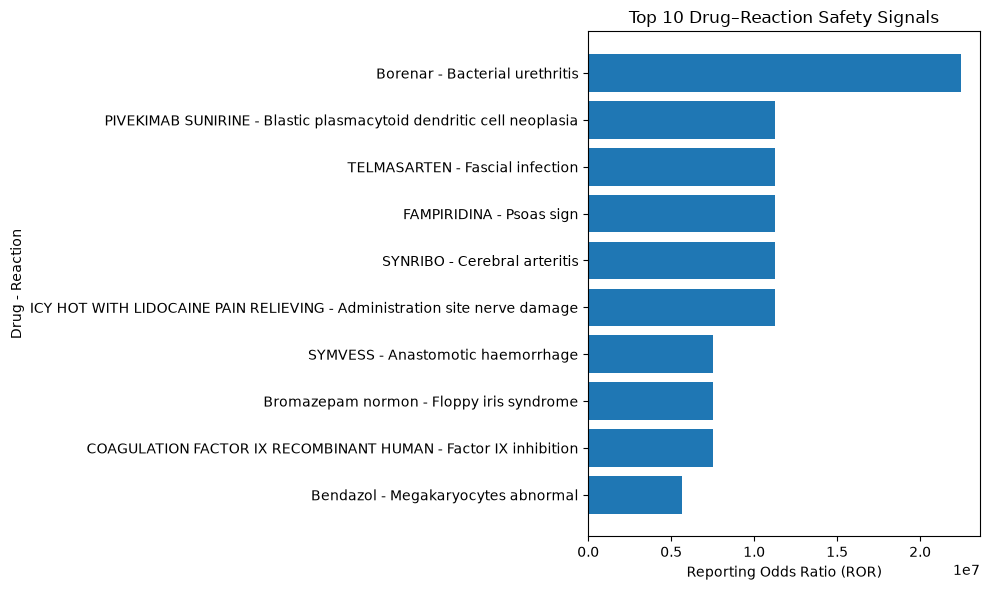

In [13]:
import matplotlib.pyplot as plt

top_signals = signal_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_signals["drugname"] + " - " + top_signals["reaction"],
    top_signals["ROR"]
)

plt.xlabel("Reporting Odds Ratio (ROR)")
plt.ylabel("Drug - Reaction")
plt.title("Top 10 Drug–Reaction Safety Signals")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
chart_output = r"C:\MCA_Projects\SafetySignal-X\outputs\top_10_ror_signals_Q1_Q2_2025.png"

plt.savefig(chart_output, dpi=300, bbox_inches="tight")

print("Chart saved successfully!")
print("Saved at:")
print(chart_output)

Chart saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\outputs\top_10_ror_signals_Q1_Q2_2025.png


<Figure size 640x480 with 0 Axes>

In [15]:
top_20_signals = signal_results.head(20).copy()

print("Top 20 Safety Signals:")
display(
    top_20_signals[
        ["drugname", "reaction", "a", "b", "c", "d", "ROR"]
    ]
)

Top 20 Safety Signals:


,drugname,reaction,a,b,c,d,ROR
2313580,Borenar,Bacterial urethritis,1,1,1,22483797,2.248380e+07
1854758,PIVEKIMAB SUNIRINE,Blastic plasmacytoid dendritic cell neoplasia,1,2,1,22483796,1.124190e+07
2641363,TELMASARTEN,Fascial infection,1,1,2,22483796,1.124190e+07
2645618,FAMPIRIDINA,Psoas sign,1,1,2,22483796,1.124190e+07
1695129,SYNRIBO,Cerebral arteritis,1,1,2,22483796,1.124190e+07
1497431,ICY HOT WITH LIDOCAINE PAIN RELIEVING,Administration site nerve damage,1,2,1,22483796,1.124190e+07
1854190,SYMVESS,Anastomotic haemorrhage,1,1,3,22483795,7.494598e+06
2657721,Bromazepam normon,Floppy iris syndrome,1,1,3,22483795,7.494598e+06
1823264,COAGULATION FACTOR IX RECOMBINANT HUMAN,Factor IX inhibition,1,3,1,22483795,7.494598e+06
2678359,Bendazol,Megakaryocytes abnormal,1,2,2,22483795,5.620949e+06


In [16]:
top20_output = r"C:\MCA_Projects\SafetySignal-X\outputs\top_20_safety_signals_Q1_Q2_2025.csv"

top_20_signals.to_csv(
    top20_output,
    index=False
)

print("Top 20 Safety Signals saved successfully!")
print("Saved at:")
print(top20_output)

Top 20 Safety Signals saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\outputs\top_20_safety_signals_Q1_Q2_2025.csv


In [19]:
import numpy as np

signal_results["ROR_95CI_lower"] = np.exp(
    np.log(signal_results["ROR"]) -
    1.96 * np.sqrt(
        1 / signal_results["a"] +
        1 / signal_results["b"] +
        1 / signal_results["c"] +
        1 / signal_results["d"]
    )
)

signal_results["ROR_95CI_upper"] = np.exp(
    np.log(signal_results["ROR"]) +
    1.96 * np.sqrt(
        1 / signal_results["a"] +
        1 / signal_results["b"] +
        1 / signal_results["c"] +
        1 / signal_results["d"]
    )
)

print("95% confidence intervals calculated successfully!")

display(
    signal_results[
        [
            "drugname",
            "reaction",
            "ROR",
            "ROR_95CI_lower",
            "ROR_95CI_upper"
        ]
    ].head(20)
)

95% confidence intervals calculated successfully!


,drugname,reaction,ROR,ROR_95CI_lower,ROR_95CI_upper
2313580,Borenar,Bacterial urethritis,2.248380e+07,754255.060582,6.702257e+08
1854758,PIVEKIMAB SUNIRINE,Blastic plasmacytoid dendritic cell neoplasia,1.124190e+07,506928.939946,2.493057e+08
2641363,TELMASARTEN,Fascial infection,1.124190e+07,506928.939946,2.493057e+08
2645618,FAMPIRIDINA,Psoas sign,1.124190e+07,506928.939946,2.493057e+08
1695129,SYNRIBO,Cerebral arteritis,1.124190e+07,506928.939946,2.493057e+08
1497431,ICY HOT WITH LIDOCAINE PAIN RELIEVING,Administration site nerve damage,1.124190e+07,506928.939946,2.493057e+08
1854190,SYMVESS,Anastomotic haemorrhage,7.494598e+06,375398.577647,1.496250e+08
2657721,Bromazepam normon,Floppy iris syndrome,7.494598e+06,375398.577647,1.496250e+08
1823264,COAGULATION FACTOR IX RECOMBINANT HUMAN,Factor IX inhibition,7.494598e+06,375398.577647,1.496250e+08
2678359,Bendazol,Megakaryocytes abnormal,5.620949e+06,351565.884671,8.986954e+07


In [20]:
ci_output = r"C:\MCA_Projects\SafetySignal-X\outputs\ror_signal_results_with_CI_Q1_Q2_2025.csv"

signal_results.to_csv(
    ci_output,
    index=False
)

print("ROR results with 95% CI saved successfully!")
print("Saved at:")
print(ci_output)

ROR results with 95% CI saved successfully!
Saved at:
C:\MCA_Projects\SafetySignal-X\outputs\ror_signal_results_with_CI_Q1_Q2_2025.csv


In [22]:
import importlib.util

print("DuckDB installed:", importlib.util.find_spec("duckdb") is not None)

DuckDB installed: False


In [23]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "duckdb"
])

print("DuckDB installed successfully!")

DuckDB installed successfully!


In [24]:
import duckdb

file_path = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"

print("DuckDB is ready.")
print("Starting corrected ROR calculation...")

DuckDB is ready.
Starting corrected ROR calculation...


In [26]:
import pandas as pd
from collections import Counter

input_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_reaction_Q1_Q2_2025.csv"
output_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\reduced_data.csv"

drug_counts = Counter()
reaction_counts = Counter()

for chunk in pd.read_csv(input_file, usecols=["drugname", "pt"], chunksize=500000):
    drug_counts.update(chunk["drugname"].dropna().astype(str))
    reaction_counts.update(chunk["pt"].dropna().astype(str))

top_drugs = {x[0] for x in drug_counts.most_common(20)}
top_reactions = {x[0] for x in reaction_counts.most_common(20)}

first = True

for chunk in pd.read_csv(input_file, usecols=["primaryid","drugname","role_cod","pt"], chunksize=500000):
    reduced = chunk[
        chunk["drugname"].isin(top_drugs) &
        chunk["pt"].isin(top_reactions)
    ]

    if not reduced.empty:
        reduced.to_csv(output_file, mode="w" if first else "a",
                       header=first, index=False)
        first = False

print("Reduced dataset created!")
print(output_file)

Reduced dataset created!
C:\MCA_Projects\SafetySignal-X\data\processed\reduced_data.csv


In [27]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\reduced_data.csv"

df = pd.read_csv(file)

print("Reduced data loaded!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Reduced data loaded!
Rows: 443472
Columns: ['primaryid', 'drugname', 'role_cod', 'pt']


In [28]:
import pandas as pd
import numpy as np

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\reduced_data.csv"
output = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_reduced.csv"

df = pd.read_csv(file)

# Remove duplicate report-drug-reaction combinations
df = df.drop_duplicates(["primaryid", "drugname", "pt"])

total_reports = df["primaryid"].nunique()

# Number of reports for each drug
drug_counts = df.groupby("drugname")["primaryid"].nunique()

# Number of reports for each reaction
reaction_counts = df.groupby("pt")["primaryid"].nunique()

# Number of reports containing both drug and reaction
pair_counts = (
    df.groupby(["drugname", "pt"])["primaryid"]
    .nunique()
    .reset_index(name="a")
)

# Calculate ROR
results = []

for _, row in pair_counts.iterrows():

    drug = row["drugname"]
    reaction = row["pt"]
    a = row["a"]

    b = drug_counts[drug] - a
    c = reaction_counts[reaction] - a
    d = total_reports - a - b - c

    if b > 0 and c > 0 and d > 0:
        ror = (a * d) / (b * c)

        results.append({
            "drugname": drug,
            "reaction": reaction,
            "a": a,
            "b": b,
            "c": c,
            "d": d,
            "ROR": ror
        })

ror_results = pd.DataFrame(results)

ror_results = ror_results.sort_values(
    "ROR",
    ascending=False
)

ror_results.to_csv(output, index=False)

print("Corrected ROR calculation completed!")
print("Signal pairs:", len(ror_results))
print("Saved to:")
print(output)

display(ror_results.head(20))

Corrected ROR calculation completed!
Signal pairs: 400
Saved to:
C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_reduced.csv


,drugname,reaction,a,b,c,d,ROR
156,DUPIXENT,Pruritus,10039,21846,3333,53438,7.367725
260,ORENCIA,Arthralgia,1802,2218,8420,76216,7.354062
33,ACTEMRA,Pain,1170,1701,7578,78207,7.098598
379,SULFASALAZINE,Vomiting,852,2084,4725,80995,7.008068
173,ENBREL,Pain,1133,1703,7615,78205,6.832504
239,LEFLUNOMIDE,Vomiting,749,1919,4828,81160,6.561175
373,SULFASALAZINE,Pain,1135,1801,7613,78107,6.465711
139,DICLOFENAC SODIUM,Vomiting,726,1882,4851,81197,6.456925
229,LEFLUNOMIDE,Malaise,710,1958,4741,81247,6.214169
377,SULFASALAZINE,Pyrexia,733,2203,4477,81243,6.037934


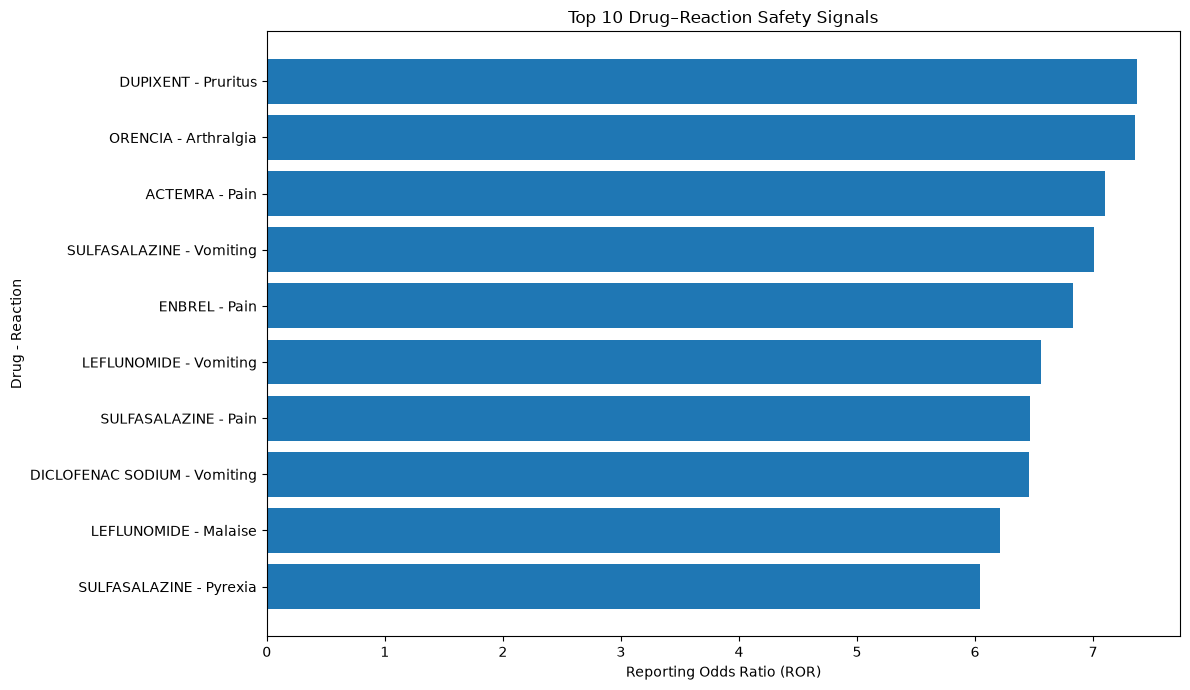

Chart created successfully!
C:\MCA_Projects\SafetySignal-X\outputs\top_10_corrected_ror_reduced.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_reduced.csv"

results = pd.read_csv(file)

top10 = results.head(10).copy()

labels = (
    top10["drugname"].astype(str)
    + " - "
    + top10["reaction"].astype(str)
)

plt.figure(figsize=(12, 7))

plt.barh(labels, top10["ROR"])

plt.xlabel("Reporting Odds Ratio (ROR)")
plt.ylabel("Drug - Reaction")
plt.title("Top 10 Drug–Reaction Safety Signals")

plt.gca().invert_yaxis()
plt.tight_layout()

chart_file = r"C:\MCA_Projects\SafetySignal-X\outputs\top_10_corrected_ror_reduced.png"

plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Chart created successfully!")
print(chart_file)

In [30]:
import pandas as pd
import numpy as np

file = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_reduced.csv"

output = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_with_CI_reduced.csv"

df = pd.read_csv(file)

# Standard error of log(ROR)
se = np.sqrt(
    1 / df["a"] +
    1 / df["b"] +
    1 / df["c"] +
    1 / df["d"]
)

# 95% confidence interval
df["ROR_95CI_lower"] = np.exp(
    np.log(df["ROR"]) - 1.96 * se
)

df["ROR_95CI_upper"] = np.exp(
    np.log(df["ROR"]) + 1.96 * se
)

df.to_csv(output, index=False)

print("95% confidence intervals added!")
print("Saved to:")
print(output)

display(df.head(20))

95% confidence intervals added!
Saved to:
C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_with_CI_reduced.csv


,drugname,reaction,a,b,c,d,ROR,ROR_95CI_lower,ROR_95CI_upper
0,DUPIXENT,Pruritus,10039,21846,3333,53438,7.367725,7.063095,7.685493
1,ORENCIA,Arthralgia,1802,2218,8420,76216,7.354062,6.883608,7.856669
2,ACTEMRA,Pain,1170,1701,7578,78207,7.098598,6.565365,7.675139
3,SULFASALAZINE,Vomiting,852,2084,4725,80995,7.008068,6.437460,7.629253
4,ENBREL,Pain,1133,1703,7615,78205,6.832504,6.315146,7.392245
5,LEFLUNOMIDE,Vomiting,749,1919,4828,81160,6.561175,6.000682,7.174021
6,SULFASALAZINE,Pain,1135,1801,7613,78107,6.465711,5.981032,6.989666
7,DICLOFENAC SODIUM,Vomiting,726,1882,4851,81197,6.456925,5.898832,7.067818
8,LEFLUNOMIDE,Malaise,710,1958,4741,81247,6.214169,5.675230,6.804287
9,SULFASALAZINE,Pyrexia,733,2203,4477,81243,6.037934,5.524737,6.598801


In [31]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_with_CI_reduced.csv"

df = pd.read_csv(file)

print("ROR results loaded!")
print("Total signal pairs:", len(df))

display(
    df[
        ["drugname", "reaction", "a", "b", "c", "d",
         "ROR", "ROR_95CI_lower", "ROR_95CI_upper"]
    ].head(20)
)

ROR results loaded!
Total signal pairs: 400


,drugname,reaction,a,b,c,d,ROR,ROR_95CI_lower,ROR_95CI_upper
0,DUPIXENT,Pruritus,10039,21846,3333,53438,7.367725,7.063095,7.685493
1,ORENCIA,Arthralgia,1802,2218,8420,76216,7.354062,6.883608,7.856669
2,ACTEMRA,Pain,1170,1701,7578,78207,7.098598,6.565365,7.675139
3,SULFASALAZINE,Vomiting,852,2084,4725,80995,7.008068,6.437460,7.629253
4,ENBREL,Pain,1133,1703,7615,78205,6.832504,6.315146,7.392245
5,LEFLUNOMIDE,Vomiting,749,1919,4828,81160,6.561175,6.000682,7.174021
6,SULFASALAZINE,Pain,1135,1801,7613,78107,6.465711,5.981032,6.989666
7,DICLOFENAC SODIUM,Vomiting,726,1882,4851,81197,6.456925,5.898832,7.067818
8,LEFLUNOMIDE,Malaise,710,1958,4741,81247,6.214169,5.675230,6.804287
9,SULFASALAZINE,Pyrexia,733,2203,4477,81243,6.037934,5.524737,6.598801


In [32]:
import pandas as pd

input_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\reduced_data.csv"

output_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\nlp_data.csv"

df = pd.read_csv(input_file)

# Keep only the columns needed for NLP
nlp_df = df[["primaryid", "drugname", "pt"]].copy()

# Remove missing values
nlp_df = nlp_df.dropna()

# Remove duplicate records
nlp_df = nlp_df.drop_duplicates()

nlp_df.to_csv(output_file, index=False)

print("NLP dataset created successfully!")
print("Rows:", len(nlp_df))
print("Saved to:")
print(output_file)

display(nlp_df.head(10))

NLP dataset created successfully!
Rows: 443120
Saved to:
C:\MCA_Projects\SafetySignal-X\data\processed\nlp_data.csv


,primaryid,drugname,pt
0,101366744,METHOTREXATE,Pneumonia
1,1016133064,ACTEMRA,Off label use
2,1016133064,ACTEMRA,Nausea
3,1016133064,ACTEMRA,Asthenia
4,1016133064,ACTEMRA,Fatigue
5,1016133064,ACTEMRA,Pain
6,1016133064,ACTEMRA,Arthralgia
7,1016133064,METHOTREXATE,Off label use
8,1016133064,METHOTREXATE,Nausea
9,1016133064,METHOTREXATE,Asthenia


In [33]:
import pandas as pd
import re

input_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\nlp_data.csv"

output_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\nlp_cleaned_data.csv"

df = pd.read_csv(input_file)

def clean_text(text):
    text = str(text).upper()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

df["drugname_clean"] = df["drugname"].apply(clean_text)
df["reaction_clean"] = df["pt"].apply(clean_text)

df.to_csv(output_file, index=False)

print("NLP cleaning completed!")
print("Rows:", len(df))
print("Saved to:")
print(output_file)

display(df.head(10))

NLP cleaning completed!
Rows: 443120
Saved to:
C:\MCA_Projects\SafetySignal-X\data\processed\nlp_cleaned_data.csv


,primaryid,drugname,pt,drugname_clean,reaction_clean
0,101366744,METHOTREXATE,Pneumonia,METHOTREXATE,PNEUMONIA
1,1016133064,ACTEMRA,Off label use,ACTEMRA,OFF LABEL USE
2,1016133064,ACTEMRA,Nausea,ACTEMRA,NAUSEA
3,1016133064,ACTEMRA,Asthenia,ACTEMRA,ASTHENIA
4,1016133064,ACTEMRA,Fatigue,ACTEMRA,FATIGUE
5,1016133064,ACTEMRA,Pain,ACTEMRA,PAIN
6,1016133064,ACTEMRA,Arthralgia,ACTEMRA,ARTHRALGIA
7,1016133064,METHOTREXATE,Off label use,METHOTREXATE,OFF LABEL USE
8,1016133064,METHOTREXATE,Nausea,METHOTREXATE,NAUSEA
9,1016133064,METHOTREXATE,Asthenia,METHOTREXATE,ASTHENIA


In [34]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\nlp_cleaned_data.csv"

df = pd.read_csv(file)

reaction_summary = (
    df["reaction_clean"]
    .value_counts()
    .head(20)
    .reset_index()
)

reaction_summary.columns = ["Reaction", "Frequency"]

print("Top 20 adverse reactions:")
display(reaction_summary)

Top 20 adverse reactions:


,Reaction,Frequency
0,OFF LABEL USE,39318
1,DRUG INEFFECTIVE,31164
2,FATIGUE,29470
3,PAIN,27154
4,ARTHRALGIA,26275
5,RASH,25483
6,CONDITION AGGRAVATED,24474
7,HEADACHE,23618
8,PRURITUS,22782
9,NAUSEA,21736


In [35]:
import pandas as pd

ror_file = r"C:\MCA_Projects\SafetySignal-X\outputs\corrected_ror_with_CI_reduced.csv"
nlp_file = r"C:\MCA_Projects\SafetySignal-X\data\processed\nlp_cleaned_data.csv"

output_file = r"C:\MCA_Projects\SafetySignal-X\outputs\final_safety_signals.csv"

ror = pd.read_csv(ror_file)
nlp = pd.read_csv(nlp_file)

# Count how many reports contain each drug-reaction pair
pair_frequency = (
    nlp.groupby(["drugname_clean", "reaction_clean"])
    .size()
    .reset_index(name="report_frequency")
)

# Rename columns so they match the ROR table
pair_frequency = pair_frequency.rename(columns={
    "drugname_clean": "drugname",
    "reaction_clean": "reaction"
})

# Make names consistent
ror["drugname"] = ror["drugname"].astype(str).str.upper().str.strip()
ror["reaction"] = ror["reaction"].astype(str).str.upper().str.strip()

# Combine ROR + frequency
final_signals = ror.merge(
    pair_frequency,
    on=["drugname", "reaction"],
    how="left"
)

final_signals["report_frequency"] = (
    final_signals["report_frequency"].fillna(0).astype(int)
)

# Sort by ROR
final_signals = final_signals.sort_values(
    "ROR",
    ascending=False
)

final_signals.to_csv(output_file, index=False)

print("Final safety-signal table created!")
print("Total signal pairs:", len(final_signals))
print("Saved to:")
print(output_file)

display(final_signals.head(20))

Final safety-signal table created!
Total signal pairs: 400
Saved to:
C:\MCA_Projects\SafetySignal-X\outputs\final_safety_signals.csv


,drugname,reaction,a,b,c,d,ROR,ROR_95CI_lower,ROR_95CI_upper,report_frequency
0,DUPIXENT,PRURITUS,10039,21846,3333,53438,7.367725,7.063095,7.685493,10039
1,ORENCIA,ARTHRALGIA,1802,2218,8420,76216,7.354062,6.883608,7.856669,1802
2,ACTEMRA,PAIN,1170,1701,7578,78207,7.098598,6.565365,7.675139,1170
3,SULFASALAZINE,VOMITING,852,2084,4725,80995,7.008068,6.437460,7.629253,852
4,ENBREL,PAIN,1133,1703,7615,78205,6.832504,6.315146,7.392245,1133
5,LEFLUNOMIDE,VOMITING,749,1919,4828,81160,6.561175,6.000682,7.174021,749
6,SULFASALAZINE,PAIN,1135,1801,7613,78107,6.465711,5.981032,6.989666,1135
7,DICLOFENAC SODIUM,VOMITING,726,1882,4851,81197,6.456925,5.898832,7.067818,726
8,LEFLUNOMIDE,MALAISE,710,1958,4741,81247,6.214169,5.675230,6.804287,710
9,SULFASALAZINE,PYREXIA,733,2203,4477,81243,6.037934,5.524737,6.598801,733


In [36]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

file = r"C:\MCA_Projects\SafetySignal-X\outputs\final_safety_signals.csv"

df = pd.read_csv(file)

# Create a simple signal label
df["signal"] = (
    (df["ROR"] > 1) &
    (df["ROR_95CI_lower"] > 1) &
    (df["report_frequency"] >= 3)
).astype(int)

features = [
    "a",
    "b",
    "c",
    "d",
    "ROR",
    "ROR_95CI_lower",
    "ROR_95CI_upper",
    "report_frequency"
]

X = df[features].fillna(0)
y = df["signal"]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X, y)

df["ML_signal_score"] = model.predict_proba(X)[:, 1]

df = df.sort_values(
    "ML_signal_score",
    ascending=False
)

output = r"C:\MCA_Projects\SafetySignal-X\outputs\ml_ranked_signals.csv"

df.to_csv(output, index=False)

print("ML signal ranking completed!")
print("Saved to:")
print(output)

display(
    df[
        ["drugname", "reaction", "ROR",
         "report_frequency", "ML_signal_score"]
    ].head(20)
)

ML signal ranking completed!
Saved to:
C:\MCA_Projects\SafetySignal-X\outputs\ml_ranked_signals.csv


,drugname,reaction,ROR,report_frequency,ML_signal_score
338,VITAMIN D3,ARTHRALGIA,1.205377,1060,1.0
337,ACETAMINOPHEN,CONDITION AGGRAVATED,1.260898,1461,1.0
336,PANTOPRAZOLE,DRUG INEFFECTIVE,1.283370,1056,1.0
31,ACTEMRA,HEADACHE,5.171689,927,1.0
30,ADALIMUMAB,MALAISE,5.173134,733,1.0
29,ENBREL,VOMITING,5.189578,678,1.0
28,DICLOFENAC SODIUM,DIZZINESS,5.236102,605,1.0
27,ORENCIA,PAIN,5.298885,1353,1.0
26,DICLOFENAC SODIUM,NASOPHARYNGITIS,5.301169,661,1.0
25,DICLOFENAC SODIUM,MALAISE,5.304490,625,1.0


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\outputs\final_safety_signals.csv"

df = pd.read_csv(file)

features = [
    "a",
    "b",
    "c",
    "d",
    "ROR",
    "ROR_95CI_lower",
    "ROR_95CI_upper",
    "report_frequency"
]

X = df[features].fillna(0)
y = (
    (df["ROR"] > 1) &
    (df["ROR_95CI_lower"] > 1) &
    (df["report_frequency"] >= 3)
).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("ML MODEL EVALUATION")
print("-------------------")
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

ML MODEL EVALUATION
-------------------
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        69

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



Feature importance:


,Feature,Importance
5,ROR_95CI_lower,0.337049
4,ROR,0.304123
6,ROR_95CI_upper,0.202861
1,b,0.051734
3,d,0.043252
0,a,0.028583
7,report_frequency,0.022362
2,c,0.010036


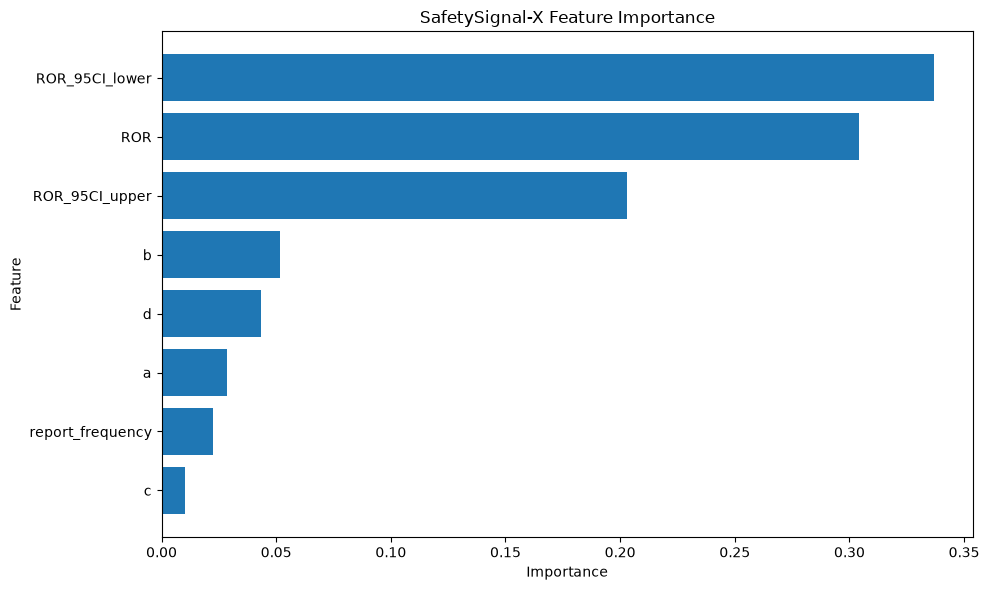

Chart saved to:
C:\MCA_Projects\SafetySignal-X\outputs\feature_importance.png


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\MCA_Projects\SafetySignal-X\outputs\final_safety_signals.csv"

df = pd.read_csv(file)

features = [
    "a",
    "b",
    "c",
    "d",
    "ROR",
    "ROR_95CI_lower",
    "ROR_95CI_upper",
    "report_frequency"
]

X = df[features].fillna(0)

# Train the model again
from sklearn.ensemble import RandomForestClassifier

y = (
    (df["ROR"] > 1) &
    (df["ROR_95CI_lower"] > 1) &
    (df["report_frequency"] >= 3)
).astype(int)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X, y)

# Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Feature importance:")
display(importance)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("SafetySignal-X Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

chart_file = r"C:\MCA_Projects\SafetySignal-X\outputs\feature_importance.png"

plt.savefig(
    chart_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Chart saved to:")
print(chart_file)

In [39]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\outputs\ml_ranked_signals.csv"

df = pd.read_csv(file)

summary = df[
    [
        "drugname",
        "reaction",
        "ROR",
        "ROR_95CI_lower",
        "ROR_95CI_upper",
        "report_frequency",
        "ML_signal_score"
    ]
].head(20)

print("Top 20 Safety Signals")
display(summary)

Top 20 Safety Signals


,drugname,reaction,ROR,ROR_95CI_lower,ROR_95CI_upper,report_frequency,ML_signal_score
0,VITAMIN D3,ARTHRALGIA,1.205377,1.125868,1.290500,1060,1.0
1,ACETAMINOPHEN,CONDITION AGGRAVATED,1.260898,1.188001,1.338269,1461,1.0
2,PANTOPRAZOLE,DRUG INEFFECTIVE,1.283370,1.197025,1.375943,1056,1.0
3,ACTEMRA,HEADACHE,5.171689,4.765241,5.612805,927,1.0
4,ADALIMUMAB,MALAISE,5.173134,4.738911,5.647144,733,1.0
5,ENBREL,VOMITING,5.189578,4.738258,5.683887,678,1.0
6,DICLOFENAC SODIUM,DIZZINESS,5.236102,4.758860,5.761205,605,1.0
7,ORENCIA,PAIN,5.298885,4.942454,5.681021,1353,1.0
8,DICLOFENAC SODIUM,NASOPHARYNGITIS,5.301169,4.832339,5.815485,661,1.0
9,DICLOFENAC SODIUM,MALAISE,5.304490,4.826252,5.830118,625,1.0


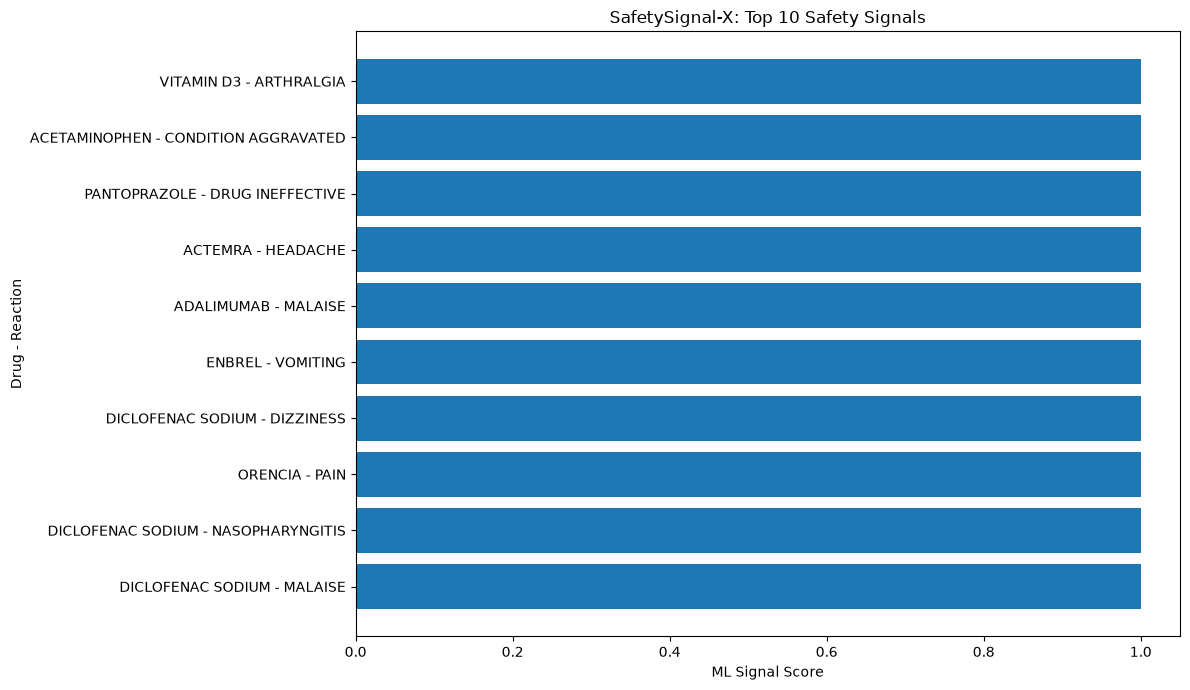

Dashboard chart created!
C:\MCA_Projects\SafetySignal-X\outputs\safetysignal_dashboard_chart.png


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

file = r"C:\MCA_Projects\SafetySignal-X\outputs\ml_ranked_signals.csv"

df = pd.read_csv(file)

top10 = df.head(10).copy()

labels = (
    top10["drugname"].astype(str)
    + " - "
    + top10["reaction"].astype(str)
)

plt.figure(figsize=(12, 7))

plt.barh(labels, top10["ML_signal_score"])

plt.xlabel("ML Signal Score")
plt.ylabel("Drug - Reaction")
plt.title("SafetySignal-X: Top 10 Safety Signals")

plt.gca().invert_yaxis()
plt.tight_layout()

output = r"C:\MCA_Projects\SafetySignal-X\outputs\safetysignal_dashboard_chart.png"

plt.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Dashboard chart created!")
print(output)

In [2]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "PANTOPRAZOLE",
    "generic_name": "pantoprazole",
    "common_uses": "Treatment of erosive esophagitis associated with GERD, maintenance of healing of erosive esophagitis, and pathological hypersecretory conditions including Zollinger-Ellison syndrome",
    "potential_benefits": "Reduces stomach acid production and helps heal or control acid-related conditions covered by the approved labeling",
    "important_risks_or_adverse_effects": "Headache, diarrhea, nausea and abdominal discomfort can occur; longer-term PPI therapy has additional risks described in the prescribing information",
    "dosage": "For adults with erosive esophagitis associated with GERD, a current delayed-release tablet label recommends 40 mg once daily for up to 8 weeks; other conditions use different regimens",
    "half_life_or_body_presence": "The terminal elimination half-life of pantoprazole is approximately 1 hour",
    "who_can_use": "Adults and, for certain labeled uses, pediatric patients 5 years and older who meet the approved indication and dosing criteria",
    "important_precautions": "Use according to the specific prescription and formulation; check contraindications and important drug interactions in the prescribing information",
    "source": "DailyMed",
    "source_url": "https://dailymed.nlm.nih.gov/dailymed/search.cfm?query=pantoprazole"
}

if not (df["drug"].astype(str).str.upper().str.strip() == "PANTOPRAZOLE").any():
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(file, index=False)
    print("PANTOPRAZOLE added successfully!")
else:
    print("PANTOPRAZOLE is already present.")

print("Total drugs:", len(df))

PANTOPRAZOLE added successfully!
Total drugs: 23


In [3]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "LEFLUNOMIDE",
    "generic_name": "leflunomide",
    "common_uses": "Treatment of active rheumatoid arthritis in adults",
    "potential_benefits": "Helps reduce the signs and symptoms of rheumatoid arthritis and can improve physical function",
    "important_risks_or_adverse_effects": "Liver injury, diarrhea, nausea, rash, hair loss, high blood pressure, low blood-cell counts, infections and other serious adverse effects can occur",
    "dosage": "Recommended maintenance dose is 20 mg once daily. In selected patients at low risk for hepatotoxicity and myelosuppression, treatment may include 100 mg once daily for 3 days as a loading dose before 20 mg once daily",
    "half_life_or_body_presence": "Leflunomide is converted to the active metabolite teriflunomide, which has a median half-life of about 18–19 days. Without an accelerated elimination procedure, it may take up to 2 years for levels to fall below a specified threshold",
    "who_can_use": "Adults with active rheumatoid arthritis who meet the approved indication and are treated under medical supervision",
    "important_precautions": "Contraindicated in pregnancy and severe hepatic impairment. Liver function, blood pressure and blood counts should be monitored. An accelerated drug-elimination procedure may be required in certain situations",
    "source": "DailyMed",
    "source_url": "https://www.dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=006b5bf4-97c0-48dc-8e5e-3c6f64d7bdc1"
}

if not (df["drug"].astype(str).str.upper().str.strip() == "LEFLUNOMIDE").any():
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(file, index=False)
    print("LEFLUNOMIDE added successfully!")
else:
    print("LEFLUNOMIDE is already present.")

print("Total drugs:", len(df))

LEFLUNOMIDE added successfully!
Total drugs: 24


In [4]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "ENBREL",
    "generic_name": "etanercept",
    "common_uses": "Rheumatoid arthritis, psoriatic arthritis, ankylosing spondylitis, plaque psoriasis, and certain pediatric inflammatory conditions covered by the approved labeling",
    "potential_benefits": "Blocks tumor necrosis factor (TNF) and reduces signs and symptoms of approved inflammatory diseases",
    "important_risks_or_adverse_effects": "Serious infections, injection-site reactions, tuberculosis, hepatitis B reactivation, allergic reactions and other serious risks described in the prescribing information",
    "dosage": "For adults with rheumatoid arthritis, psoriatic arthritis, or ankylosing spondylitis, 50 mg once weekly is a labeled regimen. Adult plaque psoriasis uses 50 mg twice weekly for 3 months, then 50 mg once weekly. Pediatric dosing depends on weight and indication",
    "half_life_or_body_presence": "The mean serum elimination half-life is approximately 102 hours (about 4.25 days) after a 25 mg subcutaneous dose",
    "who_can_use": "Patients who meet an approved indication and applicable age criteria under medical supervision",
    "important_precautions": "Screening for tuberculosis and monitoring for infections are important. Live vaccines should generally be avoided during treatment, and certain combinations with other immune therapies may increase risk",
    "source": "DailyMed",
    "source_url": "https://dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=a002b40c-097d-47a5-957f-7a7b1807af7f"
}

if not (df["drug"].astype(str).str.upper().str.strip() == "ENBREL").any():
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(file, index=False)
    print("ENBREL added successfully!")
else:
    print("ENBREL is already present.")

print("Total drugs:", len(df))

ENBREL added successfully!
Total drugs: 25


In [7]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "DICLOFENAC SODIUM",
    "generic_name": "diclofenac sodium",
    "common_uses": "Relief of pain and inflammation in appropriate conditions, depending on the formulation",
    "potential_benefits": "Helps reduce pain and inflammation",
    "important_risks_or_adverse_effects": "Stomach irritation, ulcers, gastrointestinal bleeding, cardiovascular risks, kidney problems and allergic reactions can occur",
    "dosage": "Dose depends on the formulation, condition and patient; follow the specific product or prescription instructions",
    "half_life_or_body_presence": "Elimination time depends on the formulation and route of administration",
    "who_can_use": "Patients with an appropriate indication and formulation under medical guidance",
    "important_precautions": "Use according to the specific product directions and medical advice; NSAID warnings and contraindications apply",
    "source": "DailyMed",
    "source_url": "https://dailymed.nlm.nih.gov/dailymed/search.cfm?query=diclofenac%20sodium"
}

if not (
    df["drug"]
    .astype(str)
    .str.upper()
    .str.strip()
    == "DICLOFENAC SODIUM"
).any():

    df = pd.concat(
        [df, pd.DataFrame([new_row])],
        ignore_index=True
    )

    df.to_csv(file, index=False)

    print("DICLOFENAC SODIUM added successfully!")

else:
    print("DICLOFENAC SODIUM is already present!")

print("Total drugs:", len(df))

DICLOFENAC SODIUM added successfully!
Total drugs: 26


In [8]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "COSENTYX",
    "generic_name": "secukinumab",
    "common_uses": "Moderate to severe plaque psoriasis, active psoriatic arthritis, active ankylosing spondylitis, active non-radiographic axial spondyloarthritis, enthesitis-related arthritis, and moderate to severe hidradenitis suppurativa in patients who meet the approved criteria",
    "potential_benefits": "Reduces inflammation by blocking interleukin-17A and can improve symptoms and disease activity in approved inflammatory conditions",
    "important_risks_or_adverse_effects": "Nasopharyngitis, diarrhea, upper respiratory tract infections, injection-site reactions, hypersensitivity reactions, and increased risk of infections can occur",
    "dosage": "Dose depends on the indication, age, body weight, and route. For adult plaque psoriasis, a labeled regimen is 300 mg by subcutaneous injection at Weeks 0, 1, 2, 3, and 4, then every 4 weeks",
    "half_life_or_body_presence": "Secukinumab has a mean elimination half-life of approximately 22 to 31 days",
    "who_can_use": "Patients who meet an approved indication and applicable age and clinical criteria under healthcare-provider supervision",
    "important_precautions": "Evaluate patients for tuberculosis before starting treatment. Avoid live vaccines during treatment. Use caution in patients with inflammatory bowel disease and monitor for serious infections and hypersensitivity reactions",
    "source": "DailyMed",
    "source_url": "https://dailymed.nlm.nih.gov/dailymed/search.cfm?query=COSENTYX"
}

if not (df["drug"].astype(str).str.upper().str.strip() == "COSENTYX").any():
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(file, index=False)
    print("COSENTYX added successfully!")
else:
    print("COSENTYX is already present!")

print("Total drugs:", len(df))

COSENTYX added successfully!
Total drugs: 27


In [9]:

import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "CIMZIA",
    "generic_name": "certolizumab pegol",
    "common_uses": "Crohn's disease, rheumatoid arthritis, psoriatic arthritis, ankylosing spondylitis, non-radiographic axial spondyloarthritis, plaque psoriasis, and polyarticular juvenile idiopathic arthritis in patients who meet the approved criteria",
    "potential_benefits": "Reduces inflammatory activity by blocking tumor necrosis factor (TNF)",
    "important_risks_or_adverse_effects": "Serious infections including tuberculosis, injection-site reactions, hypersensitivity reactions, and other serious risks described in the prescribing information",
    "dosage": "Administered by subcutaneous injection. Dose depends on the condition; for adults with rheumatoid arthritis, the labeled regimen is 400 mg initially at Weeks 0, 2 and 4, followed by 200 mg every other week, with 400 mg every 4 weeks as a possible maintenance regimen",
    "half_life_or_body_presence": "Terminal elimination half-life is approximately 14 days",
    "who_can_use": "Patients who meet an approved indication and applicable age and clinical criteria under healthcare-provider supervision",
    "important_precautions": "Patients should be evaluated for tuberculosis and monitored for infections. CIMZIA should not be started during an active serious infection. Hypersensitivity and heart-failure warnings also apply",
    "source": "DailyMed",
    "source_url": "https://www.dailymed.nlm.nih.gov/dailymed/fda/fdaDrugXsl.cfm?setid=b4c2c9dc-a0bb-4d64-a667-a67ebe88392d&type=display"
}

if not (df["drug"].astype(str).str.upper().str.strip() == "CIMZIA").any():
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(file, index=False)
    print("CIMZIA added successfully!")
else:
    print("CIMZIA is already present!")

print("Total drugs:", len(df))



CIMZIA added successfully!
Total drugs: 28


In [10]:
import pandas as pd

file = r"C:\MCA_Projects\SafetySignal-X\data\processed\drug_information_20.csv"

df = pd.read_csv(file)

new_row = {
    "drug": "ADALIMUMAB",
    "generic_name": "adalimumab",
    "common_uses": "Rheumatoid arthritis, psoriatic arthritis, ankylosing spondylitis, Crohn's disease, ulcerative colitis, plaque psoriasis, hidradenitis suppurativa, and certain uveitis and juvenile idiopathic arthritis indications covered by the approved labeling",
    "potential_benefits": "Blocks tumor necrosis factor (TNF) and reduces inflammatory activity in approved conditions",
    "important_risks_or_adverse_effects": "Serious infections including tuberculosis, injection-site reactions, allergic reactions, hepatitis B reactivation, and other serious risks described in the prescribing information",
    "dosage": "Subcutaneous injection. For adult rheumatoid arthritis, psoriatic arthritis, and ankylosing spondylitis, a labeled regimen is 40 mg every other week. Other conditions use different indication-specific dosing schedules",
    "half_life_or_body_presence": "Mean terminal half-life is approximately 2 weeks, with reported values ranging from about 10 to 20 days",
    "who_can_use": "Patients who meet an approved indication and applicable age and clinical criteria under healthcare-provider supervision",
    "important_precautions": "Patients should be evaluated for tuberculosis before treatment and monitored for serious infections. Follow the prescribing information for contraindications, vaccination guidance, and other warnings",
    "source": "DailyMed",
    "source_url": "https://www.dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=608d4f0d-b19f-46d3-749a-7159aa5f933d"
}

# Remove an old ADALIMUMAB row if one already exists
df = df[
    df["drug"].astype(str).str.upper().str.strip() != "ADALIMUMAB"
]

# Add the exact dashboard drug name
df = pd.concat(
    [df, pd.DataFrame([new_row])],
    ignore_index=True
)

df.to_csv(file, index=False)

print("ADALIMUMAB added successfully!")
print("Total drugs:", len(df))

ADALIMUMAB added successfully!
Total drugs: 29


In [1]:
import os

os.chdir(r"C:\MCA_Projects\SafetySignal-X")

print("Project folder:", os.getcwd())

Project folder: C:\MCA_Projects\SafetySignal-X


In [2]:
%run src/drug_reaction_analysis.py

Finding reports for DUPIXENT...
DUPIXENT reports found: 34284
Finding adverse reactions...

Top 20 reactions reported with DUPIXENT:
                                    Adverse Reaction  Frequency
0                                           Pruritus       4852
1                                  Dermatitis atopic       4787
2                                Injection site pain       3048
3                                               Rash       2916
4               Product use in unapproved indication       2862
5                                             Eczema       2611
6                                           Dry skin       2194
7                               Condition aggravated       2054
8                                   Drug ineffective       1943
9   Inappropriate schedule of product administration       1893
10                                            Asthma       1752
11                    Accidental exposure to product       1544
12                         Exposure